# Лабораторна робота 7. Методи кластеризації (навчання без учителя)

### Дисципліна: Розпізнавання образів та комп'ютерний зір
### Група: КІ-22-1
### Студент: Савченко Андрій Олександрович

## Завдання для самостійної роботи

### 1. Розглянути наведені вище приклади.
### 2. Реалізувати всі алгоритми кластеризації, наведені в роботі, для свого варіанта, обгрунтувавши знаення відповідних параметрів.
### 3. Дати відповіді на контрольні запитання.
### 4. Відправити результати роботи у файлі lab_7_StudentLastName.ipynb до віддаленого репозиторію на GіtHub

## Варіант індивідульного завдання

Варіант 9:
<br> x_train_9:
<br> [[37 46]
<br>  [26 50]
<br>  [23  6]
<br>  [21 33]
<br>  [36 42]
<br>  [37 44]
<br>  [19  6]
<br>  [23  5]
<br>  [35 28]]
<br> y_train_9:
<br> [ 1 -1  1  1 -1  1 -1  1  1]

### Алгоритм K-середніх (Метод Ллойда):

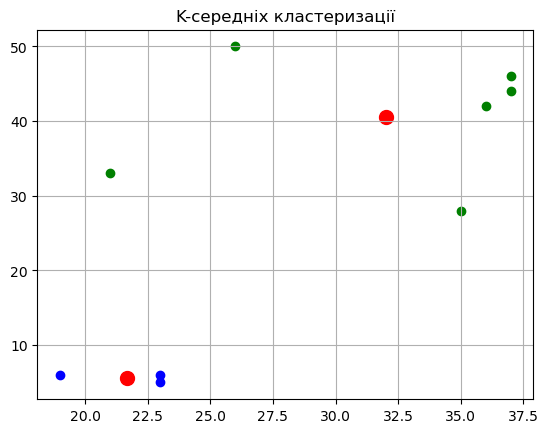

In [8]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
 [37,46],[26,50],[23,6],[21,33],[36,42],
 [37,44],[19,6],[23,5],[35,28]
])

K = 2  

centroids = X[np.random.choice(len(X), K, replace=False)]

def distance(a, b):
    return np.sqrt(np.sum((a - b)**2))
    
for _ in range(10):
    clusters = [[] for _ in range(K)]
    
    for x in X:
        d = [distance(x, c) for c in centroids]
        clusters[np.argmin(d)].append(x)
    
    centroids = [np.mean(cluster, axis=0) for cluster in clusters]

colors = ['blue', 'green']

for i in range(K):
    cluster = np.array(clusters[i])
    if len(cluster) > 0:
        plt.scatter(cluster[:,0], cluster[:,1], color=colors[i])

centroids = np.array(centroids)
plt.scatter(centroids[:,0], centroids[:,1], color='red', s=100)

plt.title("K-середніх кластеризації")
plt.grid(True)
plt.show()

### Алгоритм DBSCAN:

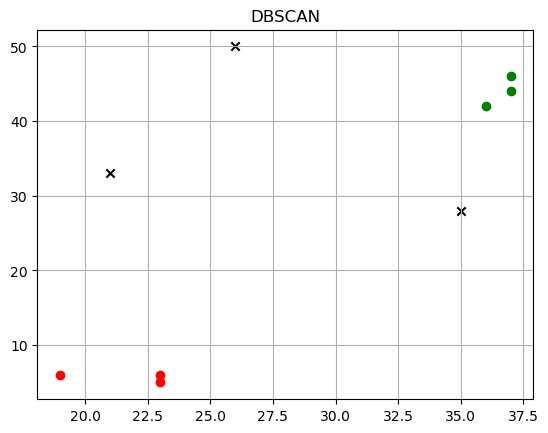

In [12]:
from itertools import cycle
from math import hypot
import matplotlib.pyplot as plt

P = [
 (37,46),(26,50),(23,6),(21,33),(36,42),
 (37,44),(19,6),(23,5),(35,28)
]

def dbscan_naive(P, eps, m, distance):
    NOISE = 0
    C = 0

    visited_points = set()
    clustered_points = set()
    clusters = {NOISE: []}

    def region_query(p):
        return [q for q in P if distance(p, q) < eps]

    def expand_cluster(p, neighbours):
        nonlocal C
        if C not in clusters:
            clusters[C] = []
        clusters[C].append(p)
        clustered_points.add(p)

        while neighbours:
            q = neighbours.pop()
            if q not in visited_points:
                visited_points.add(q)
                neighbourz = region_query(q)
                if len(neighbourz) > m:
                    neighbours.extend(neighbourz)

            if q not in clustered_points:
                clustered_points.add(q)
                clusters[C].append(q)
                if q in clusters[NOISE]:
                    clusters[NOISE].remove(q)

    for p in P:
        if p in visited_points:
            continue

        visited_points.add(p)
        neighbours = region_query(p)

        if len(neighbours) < m:
            clusters[NOISE].append(p)
        else:
            C += 1
            expand_cluster(p, neighbours)

    return clusters

eps = 10   
m = 2      

clusters = dbscan_naive(P, eps, m, lambda x, y: hypot(x[0]-y[0], x[1]-y[1]))

for c, points in zip(cycle('bgrcmyk'), clusters.values()):
    X = [p[0] for p in points]
    Y = [p[1] for p in points]
    
    if c == 'b':  # шум
        plt.scatter(X, Y, c='black', marker='x')
    else:
        plt.scatter(X, Y, c=c)

plt.title("DBSCAN")
plt.grid(True)
plt.show()

### Агломеративна ієрархічна кластеризація:


Запуск агломеративної кластеризації з K=3, метод='ward'


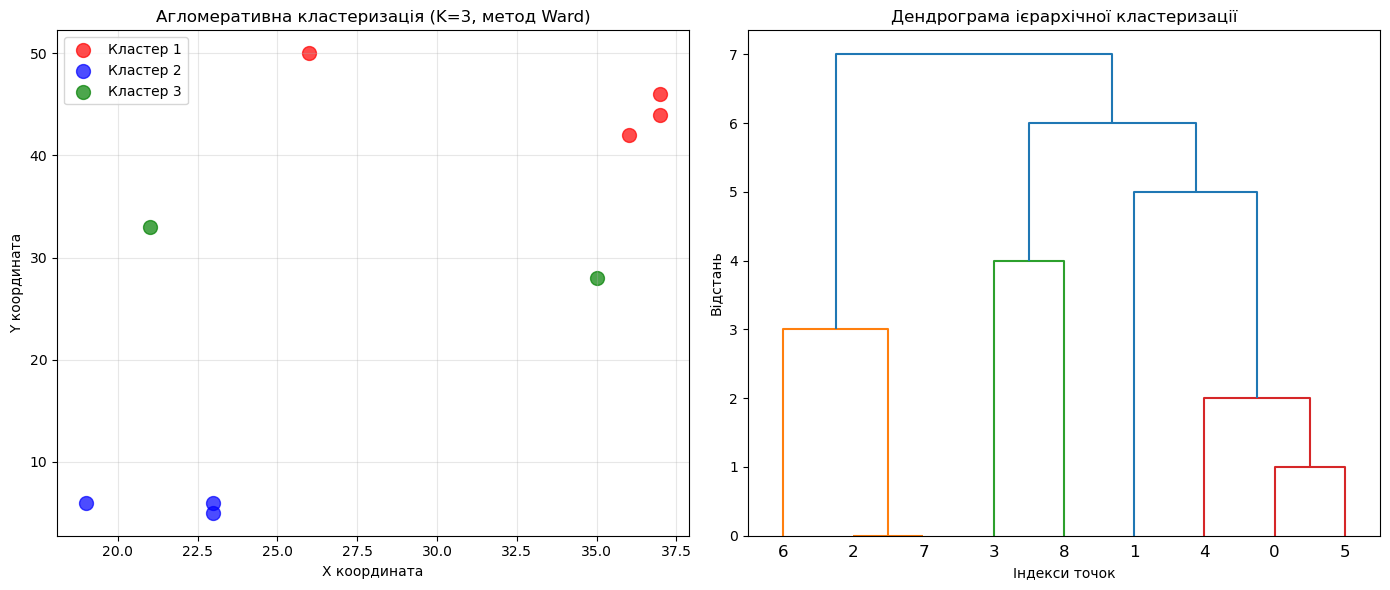

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from math import hypot
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
import time

x_train_9 = np.array([[37, 46], [26, 50], [23, 6], [21, 33], [36, 42], 
                      [37, 44], [19, 6], [23, 5], [35, 28]])
y_train_9 = np.array([1, -1, 1, 1, -1, 1, -1, 1, 1])


def plot_dendrogram(model, **kwargs):

    children = model.children_
    
    distance = np.arange(children.shape[0])
    
    no_of_observations = np.arange(2, children.shape[0] + 2)
    
    linkage_matrix = np.column_stack([children, distance, no_of_observations]).astype(float)
    
    dendrogram(linkage_matrix, **kwargs)

data_for_hierarchy = x_train_9.copy()

K = 3

print(f"\nЗапуск агломеративної кластеризації з K={K}, метод='ward'")

clustering = AgglomerativeClustering(n_clusters=K, linkage="ward")
cluster_labels = clustering.fit_predict(data_for_hierarchy)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_hier = cycle(['red', 'blue', 'green', 'orange', 'purple'])

for cluster_id in range(K):
    cluster_points = data_for_hierarchy[cluster_labels == cluster_id]
    color = next(colors_hier)
    axes[0].scatter(cluster_points[:, 0], cluster_points[:, 1], 
                   s=100, c=color, label=f'Кластер {cluster_id + 1}', alpha=0.7)

axes[0].set_title(f'Агломеративна кластеризація (K={K}, метод Ward)')
axes[0].set_xlabel('X координата')
axes[0].set_ylabel('Y координата')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

clustering_dendro = AgglomerativeClustering(n_clusters=None, linkage="ward", distance_threshold=0)
clustering_dendro.fit(data_for_hierarchy)
plot_dendrogram(clustering_dendro, ax=axes[1])
axes[1].set_title('Дендрограма ієрархічної кластеризації')
axes[1].set_xlabel('Індекси точок')
axes[1].set_ylabel('Відстань')

plt.tight_layout()
plt.show()

## Контрольні питання

### 1. У чому полягає задача кластеризації та які її цілі?
Кластеризація — це процес об'єднання об'єктів у групи (кластери) так, щоб об'єкти всередині однієї групи були максимально схожими, а об'єкти з різних груп — максимально відмінними.
<br> Головні цілі:
- Поділ клієнтів, ринків або продуктів на логічні групи.
- Заміна великої кількості точок одним представником (центроїдом).
- Об'єкти, що не потрапили в жоден кластер, часто є помилками або фродом.
- Пошук структури в даних перед основним навчанням.
### 2. Які критерії використовуються для оцінки якості розбиття об’єктів на групи у задачі кластеризації?
Внутрішні критерії аналізують лише структуру кластерів (компактність та розділеність). Приклади: Silhouette Score, індекс Девіса-Болдіна.
<br> Зовнішні критерії порівнюють результат із "ідеальним" розбиттям (якщо воно відоме). Приклади: Adjusted Rand Index (ARI), Normalized Mutual Information.
### 3. Що таке задача часткового навчання в контексті кластеризації? У чому полягаєЯка ідея алгоритму k-середніх (k-means)? У чому полягаєновна ідея алгоритму DBSCANn.
Задача часткового навчання (Semi-supervised) у кластеризації - це ситуація, коли ми маємо невелику кількість міток або обмежень. Ці знання допомагають алгоритму не просто групувати дані за геометрією, а враховувати бізнес-логіку.
<br> Ідея алгоритму k-середніх (k-means) - це ітеративний процес, що мінімізує сумарне квадратичне відхилення точок від центрів кластерів:
1. Обираємо $k$ випадкових точок (центри).
2. Призначаємо кожну точку до найближчого центру.
3. Перераховуємо центри як середнє арифметичне всіх точок у кластері.
4. Повторюємо до стабілізації.
<br> DBSCAN (Density-Based Spatial Clustering of Applications with Noise) шукає області з високою щільністю точок.
### 4. Як можна скористатися засобами бібліотеки scikit-learn для реалізації алгоритму DBSCAN на Python?
Для використання DBSCAN на Python потрібно імпортувати клас із модуля cluster.
<br> ` from sklearn.cluster import DBSCAN `
<br> ` import numpy as np `
<br> ` dbscan = DBSCAN(eps=0.5, min_samples=5) `
<br> ` clusters = dbscan.fit_predict(X) `
<br> ` print(f"Кластери: {np.unique(clusters)}") `